# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-08 13:53:59,635] A new study created in memory with name: no-name-5f7cb8f2-a3e6-4f9a-90c8-ddfb56733470
[I 2026-04-08 13:53:59,716] Trial 0 finished with value: 0.7258064516129032 and parameters: {'n_estimators': 121, 'max_depth': 3}. Best is trial 0 with value: 0.7258064516129032.
[I 2026-04-08 13:53:59,887] Trial 1 finished with value: 0.732824427480916 and parameters: {'n_estimators': 205, 'max_depth': 12}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,070] Trial 2 finished with value: 0.6942148760330579 and parameters: {'n_estimators': 222, 'max_depth': 7}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,208] Trial 3 finished with value: 0.7166666666666667 and parameters: {'n_estimators': 181, 'max_depth': 6}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,382] Trial 4 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 200, 'max_depth': 14}. Best is trial 4 with value: 0.74242424242

RF F1: 0.7368421052631579
LR F1: 0.71875
SVM F1: 0.736
KNN F1: 0.7555555555555555


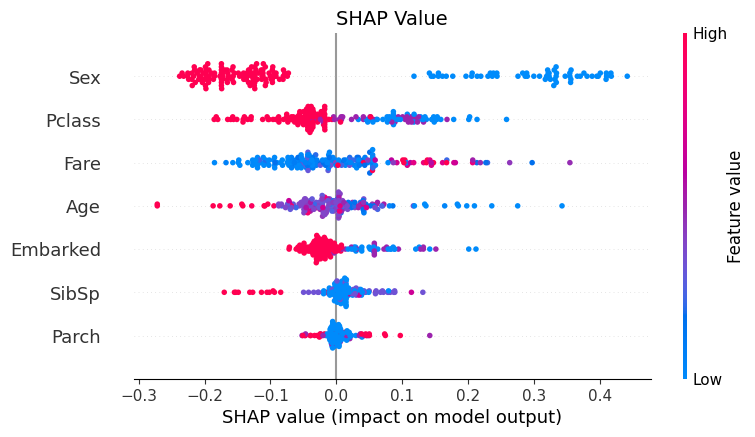

Stacking F1: 0.765625


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [1]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

In [ ]:
# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')
# 

In [3]:
# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

In [4]:
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [5]:
X = df.drop('churn', axis=1) # churn을 제외한 모든 컬럼을 특성으로 사용
y = df['churn']

# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=y)

In [7]:
from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8555,0.8496,0.4804,0.7197,0.5748,0.4921,0.5074,0.0400
lightgbm,Light Gradient Boosting Machine,0.8559,0.8499,0.4768,0.7237,0.5726,0.4907,0.5073,0.0830
gbc,Gradient Boosting Classifier,0.8614,0.8638,0.4549,0.7735,0.5708,0.4951,0.5209,0.0950
rf,Random Forest Classifier,0.8582,0.8443,0.4436,0.7601,0.5593,0.4820,0.5072,0.0950
et,Extra Trees Classifier,0.8532,0.8424,0.4269,0.7459,0.5418,0.4622,0.4883,0.0650
dt,Decision Tree Classifier,0.7862,0.6777,0.4943,0.4769,0.4849,0.3502,0.3507,0.0100
qda,Quadratic Discriminant Analysis,0.8457,0.8155,0.3243,0.8001,0.4600,0.3887,0.4434,0.0080
lda,Linear Discriminant Analysis,0.8079,0.7611,0.2112,0.5783,0.3086,0.2244,0.2633,0.0070
lr,Logistic Regression,0.8114,0.7413,0.1937,0.6174,0.2941,0.2187,0.2681,0.0480
ridge,Ridge Classifier,0.8038,0.7611,0.0964,0.6202,0.1664,0.1181,0.1863,0.0060


In [8]:
best_model

AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=42)

In [ ]:
# 데이터 로드
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)
df = df.drop(columns=['customer_id'], errors='ignore')
# 데이터 전처리로 'customer_id'칼럼을 제거함, 그 이유는 id자체가 유니크한 데이터이기 떄문에 과적합을 유발할 수 있음
# errors = 'ignore'는 해당 칼럼이 이미 삭제되었거나 없더라도 에러없이 코드가 실행이 가능해짐

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

# 번주형 데이터의 경우 수치로 나와있지 않기 떄문에 머신러닝 모델이 이해할 수가 없다.
# 따라서 인코딩을 통해 숫자로 바꿔줄 필요가 있음

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])


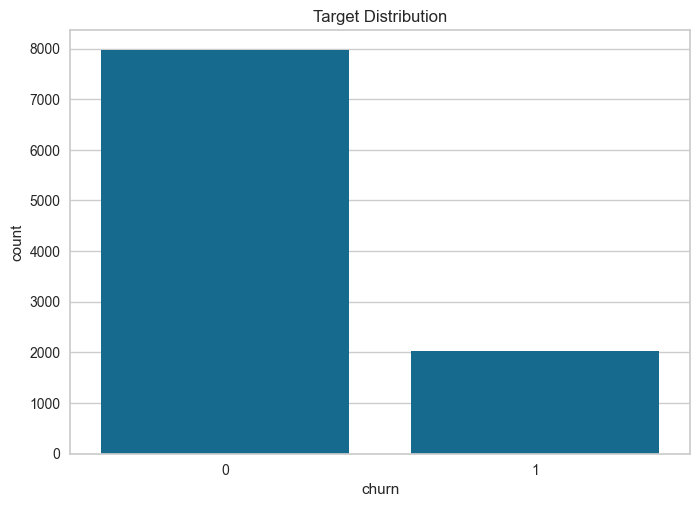

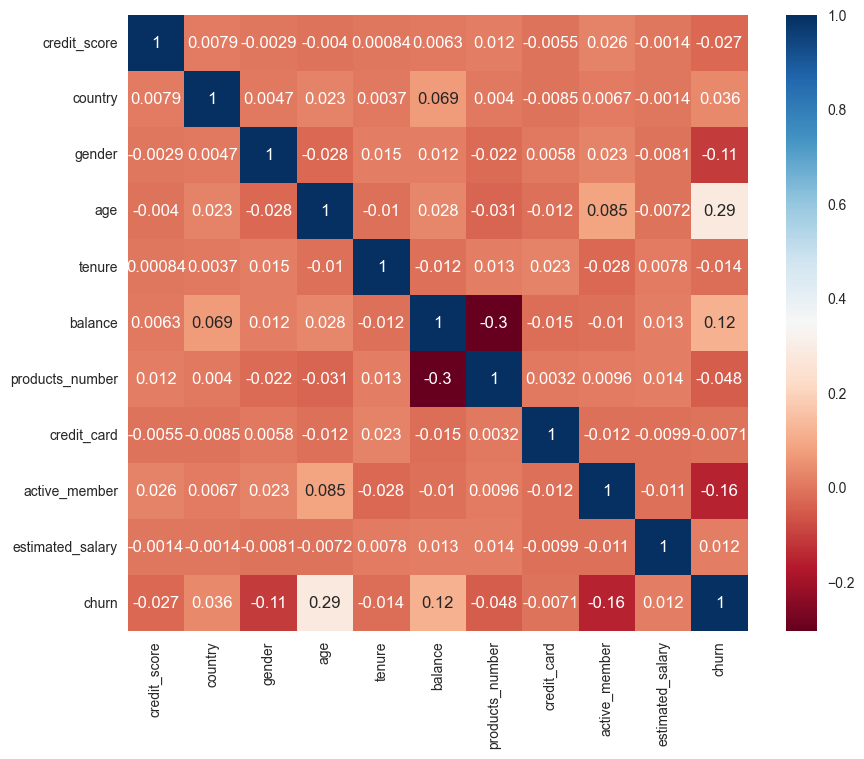

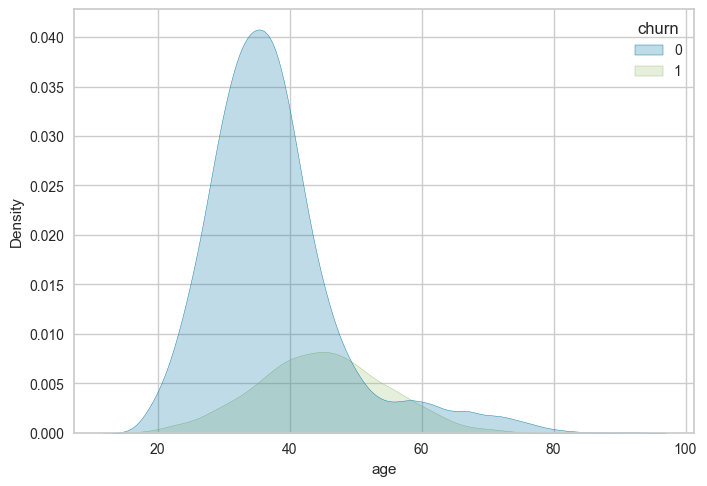

In [14]:
# EDA
import seaborn as sns
import matplotlib.pyplot as plt

# 1 churn(이탈유무)와 상관관계를 확인하기 위해 churn값의 분포를 확인함
sns.countplot(x='churn', data=df)
plt.title('Target Distribution')
plt.show()
# 0의 값, 즉 이탈하지 않는 사람이 많은 것으로 드러남

# 2 X값과 y(churn)값의 상관관계를 구하기 위해 관계를 시각화해봄
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu')
plt.show()
# 시각화를 했더니, churn과 age간에 상관점수가 가장 높게 나옴
sns.kdeplot(data=df, x='age', hue='churn', shade=True)
plt.show()
# 이 둘간의 관계를 그래프로 시각화해봄
# 둘 간의 관계 그래프에서 나이가 많은수록 이탈할 위험이 있다라고 판단됨

In [ ]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# 상위 모델 4개 : ada, gbc, dt, qda로 나옴, 각 모델 optuna로 최적의 파라미터를 찾으려함
# X, y
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 우선 변수로 y값에 churn 이탈 여부 값 그리고 x에는 churn 여부 값을 제외한 모든 값을 넣음
X = df.drop('churn', axis=1)
y = df['churn']

# train valid split
# 학습용 데이터와 시험용 데이터를 8:2로 쪼개주고, 결과의 일관성을 위해 random_state로 42를 부여함
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 스케일링
# 데이터의 단위를 맞춰주기 위해 스케일링을 진행함 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)



In [ ]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import f1_score

#pycaret을 이용해서 스코어가 잘 나오는 모델 4개를 고름,
#DT, ADA, GBC, QDA로 골랐으며 optuna를 활용해 최적의 하이퍼파라미터를 찾아감

# 1. Decision Tree (DT)
def objective_dt(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])
    }
    model = DecisionTreeClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 2. AdaBoost (ADA)
def objective_ada(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True)
    }
    model = AdaBoostClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 3. Gradient Boosting (GBC)
def objective_gbc(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0)
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 4. Quadratic Discriminant Analysis (QDA)
def objective_qda(trial):
    params = {
        'reg_param': trial.suggest_float('reg_param', 0.0, 1.0)
    }
    model = QuadraticDiscriminantAnalysis(**params)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

In [23]:
import optuna

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터를 탐색해봄
# 1. Decision Tree (dt) 최적화
study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=10)

# 2. AdaBoost (ada) 최적화
study_ada = optuna.create_study(direction='maximize')
study_ada.optimize(objective_ada, n_trials=10)

# 3. Gradient Boosting (gbc) 최적화
study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(objective_gbc, n_trials=10)

# 4. Quadratic Discriminant Analysis (qda) 최적화
study_qda = optuna.create_study(direction='maximize')
study_qda.optimize(objective_qda, n_trials=10)

[I 2026-04-09 15:21:50,057] A new study created in memory with name: no-name-2feca75d-fcef-47fa-9826-ef8841760080
[I 2026-04-09 15:21:50,099] Trial 0 finished with value: 0.5659863945578232 and parameters: {'max_depth': 14, 'min_samples_split': 14, 'min_samples_leaf': 8, 'criterion': 'gini'}. Best is trial 0 with value: 0.5659863945578232.
[I 2026-04-09 15:21:50,111] Trial 1 finished with value: 0.5391849529780565 and parameters: {'max_depth': 4, 'min_samples_split': 18, 'min_samples_leaf': 3, 'criterion': 'gini'}. Best is trial 0 with value: 0.5659863945578232.
[I 2026-04-09 15:21:50,143] Trial 2 finished with value: 0.5142118863049095 and parameters: {'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 0 with value: 0.5659863945578232.
[I 2026-04-09 15:21:50,164] Trial 3 finished with value: 0.5126475548060708 and parameters: {'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 0 with valu

In [ ]:
# Optuna로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션을 정의해봄
# 1. Decision Tree (dt)
dt = DecisionTreeClassifier(**study_dt.best_params, random_state=42)

# 2. AdaBoost (ada)
ada = AdaBoostClassifier(**study_ada.best_params, random_state=42)

# 3. Gradient Boosting (gbc)
gbc = GradientBoostingClassifier(**study_gbc.best_params, random_state=42)

# 4. Quadratic Discriminant Analysis (qda)
# QDA는 random_state 인자가 없으므로 파라미터만 넣어줌
qda = QuadraticDiscriminantAnalysis(**study_qda.best_params)

In [25]:
# 모델 학습
dt.fit(X_train, y_train)
ada.fit(X_train, y_train)
gbc.fit(X_train, y_train)
qda.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력함
# QDA는 통계 기반 모델이므로 'QDA'로 이름을 지정함
model_list = [('DT', dt), ('ADA', ada), ('GBC', gbc), ('QDA', qda)]

for name, model in model_list:
    pred = model.predict(X_valid)
    print(f"{name} F1: {f1_score(y_valid, pred):.4f}")

#결과로 GBC가 F1스코어가 제일 높게 나왔고, ADA, DT, QDA순으로 나옴

DT F1: 0.5660
ADA F1: 0.5732
GBC F1: 0.5991
QDA F1: 0.3821


In [ ]:
import shap

# SHAP value값을 구하기 위해 GBC를 지정해서 사후분석을 진행
# 트리 기반 모델이므로 TreeExplainer를 사용

explainer = shap.TreeExplainer(gbc)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업 강조 내용)
if isinstance(shap_values, list):
    # 이진 분류에서 리스트로 반환될 경우 index 1(긍정 클래스)을 선택함
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    # 3차원 배열(데이터, 특성, 클래스)인 경우 마지막 차원의 index 1을 선택함
    shap_values = shap_values[:, :, 1]
else:
    # 이미 2차원(데이터, 특성)인 경우 그대로 사용함
    shap_values = shap_values


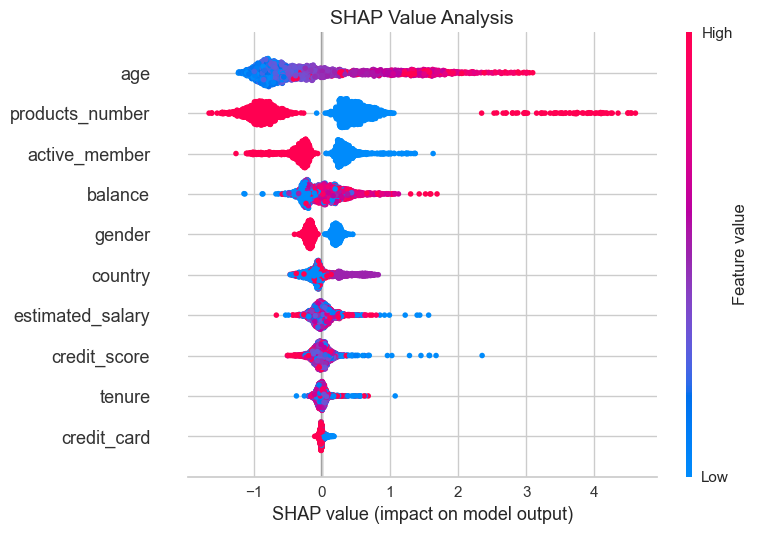

Stacking F1: 0.5816485225505443


In [29]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가


plt.figure(figsize=(10, 8)) # 그래프 크기 조정
shap.summary_plot(
    shap_values,             # SHAP value 반환값
    X_valid,                 # 평가용 데이터
    feature_names=X.columns, # 컬럼 리스트
    plot_type="dot",         # 점 형태의 그래프
    show=False               # plt 설정을 추가하기 위해 False 처리
)

# 제목 설정 및 출력
plt.title("SHAP Value Analysis", fontsize=14)
plt.tight_layout()
plt.show()

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score


# 4개 모델을 Stacking (전방모델, 후방모델 아무거나)

# 1. 전방 모델 리스트 (Base Models)
# 앞서 최적화(Optuna)를 마친 4개 모델을 리스트로 묶음
est_model_list = [
    ('dt', dt),
    ('ada', ada),
    ('gbc', gbc),
    ('qda', qda)
]

# 2. Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list,      # 전방 모델
    final_estimator = LogisticRegression(), # 후방 모델 (메타 모델)
    cv = 5                            # 교차 검증 설정 (권장)
)

# 3. 모델 학습
stack.fit(X_train, y_train)

# 4. 예측 및 성능 평가
pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

In [ ]:
#F1 스코어로 58이 나왔고 기존 F1 스코어보다 1정도 개선된 효과를 보임

#EDA를 통해 추측했던 churn과 age의 관계를 SHAP value로 다시 분석해보았을 때 실제로
# 나이가 적을수록 이탈률이 낮은 것으로 분석됨
# 
# 상관관계에서는 강하게 드러나지 않았던 product_number의 경우 products_number가 높을수록 churn값이 낮다라는 결과
# 즉, 해당 은행 상품이 많을수록 이탈률이 적고, 적을수록 이탈률이 높다라는 당연한 값이 증명됨
# active_member도 비슷한 양상을 보임

#유의미 하다고 판단되는 칼럼이 두가지 더 있는데,
# 먼저 balance잔액이다. 잔액의 경우 높을수록 오히려 churn이 높은 것으로 드러나는데 이는 거액을 가지고 있는
# 고객이 이벤트로 인한 혜택이 높은 상품 만기가 지날시 이탈을 하는 경우가 있어 그래프와 같이 나오는 것으로 추정됨

# 또 한가지는 country 나라별 특이한 양상을 띈다는 것이다
# 인코딩 결과 France(0), Germany(1), Spain(2)로 나오는데 보라색쪽이 이탈이 제일 높은
#, 독일의 고객이 가장 이탈을 많이 하는 것으로 나온다. 그 이유는 추정컨대 그 해에 독일에 경제나 정치 관련 이슈가 있지 않았을까하는 추정이 가능하다.

# 위 사후분석을 통해 제시할 수 있는 인사이트로
# 1 age가 높은 고객이 churn의 확률은 낮출 수 있는 이벤트나 상품이 필요하다는 것
# 2 잔액이 높은 고객의 경우 churn을 방지하기 위해 이탈시 패널티를 주는 등의 액션이 필요할 것으로 보인다
# 3 country의 경우 경제나 정치 관련 이슈는 방지하기 어렵지만, 특정 국가에서 이탈이 많을 경우 관려 나라 국민을 위한 이벤트가 필요할 것으로 보인다.

